# Compute metrics by site to detect biased performance.
## `uniharmony` allows you to stratify the performance metrics by site, unreveling hidden patterns.

In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

from uniharmony.metrics import report_metric_by_site


Scenario 1: Overall bad performance, one site excels
Strong site: 2
Global accuracy: 0.460
Per-site accuracy: {0: 0.45384615384615384, 1: 0.41729323308270677, 2: 0.97, 3: 0.40482954545454547}

Scenario 2: Overall good performance, but one site fails
Weak site: 2
Global accuracy: 0.846
Per-site accuracy: {0: 0.9153846153846154, 1: 0.9285714285714286, 2: 0.11, 3: 0.90625}



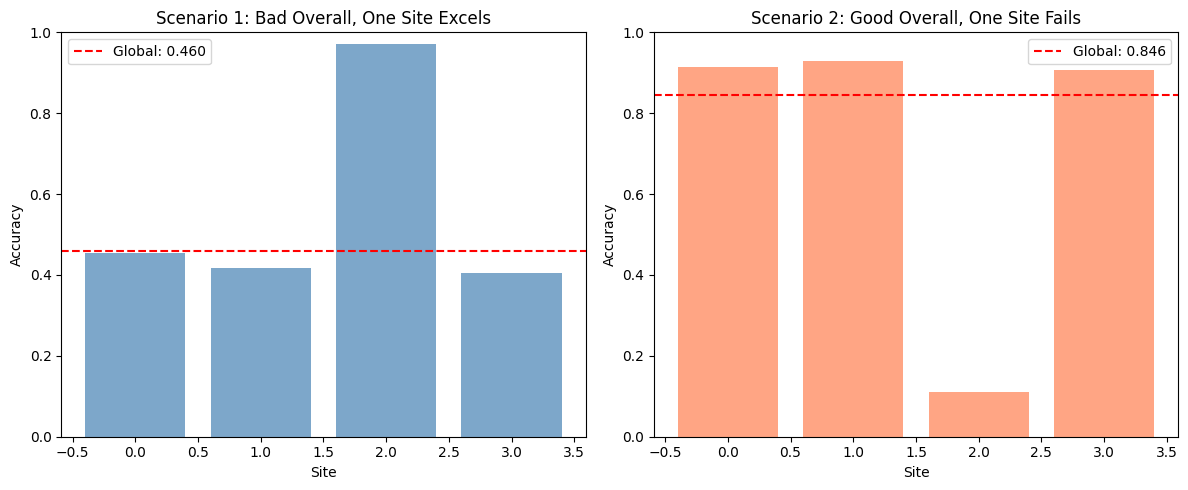

In [ ]:
# Generate site assignments and labels
rng = np.random.default_rng(23)
n_sites = 4
n_samples = 1200

site_probs = rng.dirichlet(np.ones(n_sites))
sites = rng.choice(np.arange(n_sites), size=n_samples, p=site_probs)
y_true = rng.integers(0, 2, size=n_samples)

sites_unique = np.unique(sites)
site_counts = np.bincount(sites, minlength=n_sites)
smallest_site = int(np.argmin(site_counts))


def _make_predictions_with_site_accuracy(y_true, sites, site_accuracy, rng):
    y_pred = y_true.copy()

    for site in np.unique(sites):
        mask = sites == site
        n_site = mask.sum()
        # Flip labels to reach the desired accuracy for this site
        flip = rng.random(n_site) < (1.0 - site_accuracy[site])
        site_preds = y_pred[mask]
        site_preds[flip] = 1 - site_preds[flip]
        y_pred[mask] = site_preds

    return y_pred


# Scenario 1: Overall bad performance, but one site excels
print("Scenario 1: Overall bad performance, one site excels")
strong_site = smallest_site  # keep the strong site small so overall stays poor
base_acc_s1 = rng.uniform(0.25, 0.40)
strong_acc_s1 = rng.uniform(0.95, 0.99)
site_acc_s1 = dict.fromkeys(sites_unique, base_acc_s1)
site_acc_s1[strong_site] = strong_acc_s1

y_pred_s1 = _make_predictions_with_site_accuracy(
    y_true, sites, site_acc_s1, rng
)
metric_global_s1 = accuracy_score(y_true, y_pred_s1)
metric_s1 = report_metric_by_site(
    y_true, y_pred_s1, sites, accuracy_score, overall_performance=True
)
metric_global_s1 = metric_s1.pop("overall")

print(f"Strong site: {strong_site}")
print(f"Global accuracy: {metric_global_s1:.3f}")
print(f"Per-site accuracy: {metric_s1}")
print()

# Scenario 2: Overall good performance, but one site fails badly
print("Scenario 2: Overall good performance, but one site fails")
weak_site = smallest_site  # keep the weak site small so overall stays strong
base_acc_s2 = rng.uniform(0.90, 0.97)
weak_acc_s2 = rng.uniform(0.05, 0.15)
site_acc_s2 = dict.fromkeys(sites_unique, base_acc_s2)
site_acc_s2[weak_site] = weak_acc_s2

y_pred_s2 = _make_predictions_with_site_accuracy(
    y_true, sites, site_acc_s2, rng
)
metric_s2 = report_metric_by_site(
    y_true, y_pred_s2, sites, accuracy_score, overall_performance=True
)
metric_global_s2 = metric_s2.pop("overall")
print(f"Weak site: {weak_site}")
print(f"Global accuracy: {metric_global_s2:.3f}")
print(f"Per-site accuracy: {metric_s2}")
print()

# Visualize both scenarios
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scenario 1
site_scores_s1 = [metric_s1[s] for s in sites_unique]
axes[0].bar(sites_unique, site_scores_s1, alpha=0.7, color="steelblue")
axes[0].axhline(
    metric_global_s1,
    color="red",
    linestyle="--",
    label=f"Global: {metric_global_s1:.3f}",
)
axes[0].set_xlabel("Site")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Scenario 1: Bad Overall, One Site Excels")
axes[0].legend()
axes[0].set_ylim([0, 1])
# Scenario 2
site_scores_s2 = [metric_s2[s] for s in sites_unique]
axes[1].bar(sites_unique, site_scores_s2, alpha=0.7, color="coral")
axes[1].axhline(
    metric_global_s2,
    color="red",
    linestyle="--",
    label=f"Global: {metric_global_s2:.3f}",
)
axes[1].set_xlabel("Site")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Scenario 2: Good Overall, One Site Fails")
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()
